# League of Legends player mobility network, 2015–2019 — v4

**Research questions:**

1. How do shared players connect professional teams and leagues in the 2015–2019 mobility network?
2. Is domestic performance associated with concentrating a team's recorded domestic player-games in a five-player core?
3. As a secondary question, are bridge positions related to recorded international participation?

The starting point is a processed Leaguepedia-derived player–team table. Raw API responses and the original collection/cleaning script are unavailable, so this notebook does not claim raw-data counts or reproduce earlier identity-resolution decisions. It aggregates duplicate rows for already-defined `player_node`–`team_node` pairs and performs the network analyses from that fixed processed snapshot.

The original graph is an undirected weighted **player–team bipartite graph**: a player and team are connected when the player represented that team, and edge weight is recorded games. The team–team graph used later is only a derived projection: two teams are linked when they share at least one recorded player. Shared players show association, not transfer direction or reasons for movement.


## 1. Setup and data validation

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import igraph as ig
from matplotlib.patches import Patch
import networkx as nx
from networkx.algorithms import bipartite
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import random

SEED = 403
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

# Prefer the project layout, but also accept a CSV placed beside the notebook.
ROOT = Path.cwd()
data_candidates = [
    ROOT / "data" / "processed" / "affiliations.csv",
    ROOT / "affiliations.csv",
    ROOT / "affiliations(3).csv",
    ROOT.parent / "data" / "processed" / "affiliations.csv",
]
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place affiliations.csv beside the notebook or under data/processed/.")

raw = pd.read_csv(DATA_PATH)
required_columns = {
    "player_node", "team_node", "player_name", "team_name",
    "team_name_at_time", "team_name_history", "group", "leagues",
    "minutes_domestic", "games_domestic", "wins_domestic",
    "first_date", "last_date", "active_years",
    "minutes_international", "games_international", "wins_international",
    "minutes_total", "games_total", "wins_total", "domestic_win_rate",
}
missing_columns = required_columns.difference(raw.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")
if raw[["player_node", "team_node"]].isna().any().any():
    raise ValueError("player_node and team_node must not be missing")

raw["first_date"] = pd.to_datetime(raw["first_date"], utc=True)
raw["last_date"] = pd.to_datetime(raw["last_date"], utc=True)

def split_values(values):
    result = set()
    for value in values:
        result.update(
            part.strip() for part in str(value).split("|")
            if part.strip() and part.strip().lower() != "nan"
        )
    return sorted(result)

def split_years(values):
    return sorted({int(part) for part in split_values(values)})

covered_years = split_years(raw["active_years"])
validation_summary = pd.DataFrame(
    {
        "item": [
            "Rows", "Columns", "Exact duplicate rows",
            "Duplicate player-team rows beyond first", "Unique players",
            "Unique team lineages", "Leagues", "Groups", "Covered years",
        ],
        "value": [
            len(raw), len(raw.columns), raw.duplicated().sum(),
            raw.duplicated(["player_node", "team_node"]).sum(),
            raw["player_node"].nunique(), raw["team_node"].nunique(),
            ", ".join(sorted(raw["leagues"].unique())),
            ", ".join(sorted(raw["group"].unique())),
            ", ".join(map(str, covered_years)),
        ],
    }
)
missing_value_summary = (
    raw.isna().sum().rename("missing_values").to_frame()
       .assign(missing_share=lambda x: x["missing_values"] / len(raw))
)
column_summary = pd.DataFrame({"column": raw.columns, "dtype": raw.dtypes.astype(str).values})

display(validation_summary)
display(column_summary)
display(missing_value_summary)

,item,value
0,Rows,3561
1,Columns,21
2,Exact duplicate rows,0
3,Duplicate player-team rows beyond first,134
4,Unique players,2029
5,Unique team lineages,244
6,Leagues,"CBLOL, LCK, LCL, LCS, LEC, LJL, LMS, LPL, OPL,..."
7,Groups,"major, wildcard"
8,Covered years,"2015, 2016, 2017, 2018, 2019"


,column,dtype
0,player_node,object
1,team_node,object
2,player_name,object
3,team_name,object
4,team_name_at_time,object
5,team_name_history,object
6,group,object
7,leagues,object
8,minutes_domestic,float64
9,games_domestic,int64


,missing_values,missing_share
player_node,0,0.0
team_node,0,0.0
player_name,0,0.0
team_name,0,0.0
team_name_at_time,0,0.0
team_name_history,0,0.0
group,0,0.0
leagues,0,0.0
minutes_domestic,0,0.0
games_domestic,0,0.0


### Aggregate player–team pairs

In [2]:
numeric_edge_columns = [
    "minutes_domestic", "games_domestic", "wins_domestic",
    "minutes_international", "games_international", "wins_international",
    "minutes_total", "games_total", "wins_total",
]

def join_values(values):
    return " | ".join(split_values(values))

aggregation = {
    "player_name": "last",
    "team_name": "last",
    "team_name_at_time": join_values,
    "team_name_history": join_values,
    "group": join_values,
    "leagues": join_values,
    "first_date": "min",
    "last_date": "max",
    "active_years": lambda x: "|".join(map(str, split_years(x))),
}
aggregation.update({column: "sum" for column in numeric_edge_columns})

edge_table = (
    raw.groupby(["player_node", "team_node"], as_index=False, sort=True)
       .agg(aggregation)
)
edge_table["domestic_win_rate"] = edge_table["wins_domestic"].div(
    edge_table["games_domestic"].replace(0, np.nan)
)

assert not edge_table.duplicated(["player_node", "team_node"]).any()
assert np.allclose(
    raw[numeric_edge_columns].sum().to_numpy(dtype=float),
    edge_table[numeric_edge_columns].sum().to_numpy(dtype=float),
)
print(f"Aggregated to {len(edge_table):,} unique player-team edges; numeric totals are preserved.")

Aggregated to 3,427 unique player-team edges; numeric totals are preserved.


## 2. Player–team bipartite graph

This is an undirected weighted bipartite graph. Edge weight is `games_total`. Degree counts affiliations; strength sums recorded games.

In [3]:
B = nx.Graph(name="Player-team lineage bipartite graph")

for row in edge_table.itertuples(index=False):
    display_group = "minor" if row.group == "wildcard" else row.group
    B.add_node(row.player_node, node_type="player", bipartite=0, label=row.player_name)
    B.add_node(
        row.team_node, node_type="team", bipartite=1, label=row.team_name,
        league=row.leagues, group=row.group, display_group=display_group,
        team_name_at_time=row.team_name_at_time,
        team_name_history=row.team_name_history,
    )
    B.add_edge(
        row.player_node, row.team_node,
        weight=float(row.games_total), games_total=float(row.games_total),
        games_domestic=float(row.games_domestic),
        wins_domestic=float(row.wins_domestic),
        minutes_domestic=float(row.minutes_domestic),
        games_international=float(row.games_international),
        wins_international=float(row.wins_international),
        minutes_international=float(row.minutes_international),
        minutes_total=float(row.minutes_total), wins_total=float(row.wins_total),
        first_date=row.first_date.isoformat(), last_date=row.last_date.isoformat(),
        active_years=row.active_years,
        team_name_at_time=row.team_name_at_time,
        team_name_history=row.team_name_history,
    )

assert not B.is_directed() and bipartite.is_bipartite(B)
player_nodes = {n for n, a in B.nodes(data=True) if a["node_type"] == "player"}
team_nodes = set(B) - player_nodes
components = sorted((len(c) for c in nx.connected_components(B)), reverse=True)

bipartite_summary = pd.DataFrame(
    {
        "metric": [
            "Graph type", "Nodes", "Edges", "Players", "Teams",
            "Bipartite density", "Connected components", "Giant component size",
            "Giant component share", "Average player bipartite clustering",
            "Average team bipartite clustering",
        ],
        "value": [
            "Undirected weighted bipartite", B.number_of_nodes(), B.number_of_edges(),
            len(player_nodes), len(team_nodes), bipartite.density(B, player_nodes),
            len(components), components[0], components[0] / B.number_of_nodes(),
            bipartite.average_clustering(B, nodes=player_nodes),
            bipartite.average_clustering(B, nodes=team_nodes),
        ],
    }
)

def distribution_summary(values, node_type, measure):
    series = pd.Series(values, dtype=float)
    return {
        "node_type": node_type, "measure": measure, "count": len(series),
        "min": series.min(), "q25": series.quantile(0.25),
        "median": series.median(), "mean": series.mean(),
        "q75": series.quantile(0.75), "max": series.max(),
    }

bipartite_distributions = pd.DataFrame([
    distribution_summary([B.degree(n) for n in player_nodes], "player", "degree"),
    distribution_summary([B.degree(n) for n in team_nodes], "team", "degree"),
    distribution_summary([B.degree(n, weight="weight") for n in player_nodes], "player", "strength"),
    distribution_summary([B.degree(n, weight="weight") for n in team_nodes], "team", "strength"),
])
component_size_distribution = pd.DataFrame(
    {"component_rank": range(1, len(components) + 1), "nodes": components}
).assign(share=lambda x: x["nodes"] / B.number_of_nodes())

display(bipartite_summary.round(4))
display(bipartite_distributions.round(2))
display(component_size_distribution.head(15).round(4))

,metric,value
0,Graph type,Undirected weighted bipartite
1,Nodes,2273
2,Edges,3427
3,Players,2029
4,Teams,244
5,Bipartite density,0.006922
6,Connected components,17
7,Giant component size,2157
8,Giant component share,0.948966
9,Average player bipartite clustering,0.519932


,node_type,measure,count,min,q25,median,mean,q75,max
0,player,degree,2029,1.0,1.00,1.0,1.69,2.00,7.0
1,team,degree,244,5.0,7.00,11.0,14.05,19.25,57.0
2,player,strength,2029,1.0,9.00,32.0,73.90,101.00,565.0
3,team,strength,244,10.0,108.75,360.0,614.50,921.25,3115.0


,component_rank,nodes,share
0,1,2157,0.9490
1,2,9,0.0040
2,3,9,0.0040
3,4,9,0.0040
4,5,8,0.0035
5,6,8,0.0035
6,7,8,0.0035
7,8,8,0.0035
8,9,7,0.0031
9,10,7,0.0031


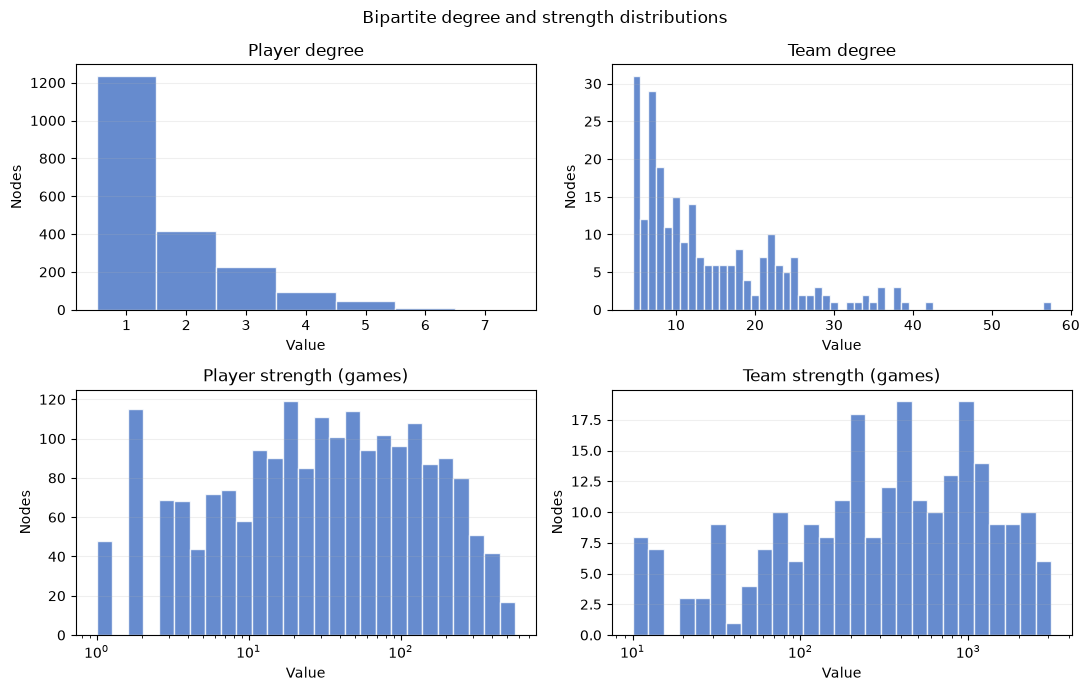

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
distribution_plots = [
    (player_nodes, "degree", "Player degree"),
    (team_nodes, "degree", "Team degree"),
    (player_nodes, "strength", "Player strength (games)"),
    (team_nodes, "strength", "Team strength (games)"),
]
for ax, (nodes, measure, title) in zip(axes.flat, distribution_plots):
    values = np.array([
        B.degree(node, weight="weight" if measure == "strength" else None)
        for node in nodes
    ], dtype=float)
    if measure == "strength":
        bins = np.geomspace(values[values > 0].min(), values.max(), 28)
        ax.set_xscale("log")
    else:
        bins = np.arange(values.min() - 0.5, values.max() + 1.5)
    ax.hist(values, bins=bins, color="#4472C4", alpha=0.82, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Nodes")
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("Bipartite degree and strength distributions")
plt.tight_layout()
plt.show()

## 3. Team shared-player projection

Two teams are connected when at least one recorded player represented both team lineages. Edge weight is the number of shared players. This is a **shared-player network**, not a directed transfer network. Eigenvector centrality is calculated on the giant component and set to zero outside it.

In [5]:
team_graph = bipartite.weighted_projected_graph(B, team_nodes, ratio=False)
for node in team_graph:
    team_graph.nodes[node].update(B.nodes[node])
for u, v, attrs in team_graph.edges(data=True):
    attrs["shared_players"] = int(attrs["weight"])
    attrs["distance"] = 1 / attrs["weight"]

def graph_centralities(graph):
    degree = dict(graph.degree())
    weighted_degree = dict(graph.degree(weight="weight"))
    betweenness = nx.betweenness_centrality(graph, weight="distance", normalized=True)
    harmonic = nx.harmonic_centrality(graph, distance="distance")
    eigenvector = {node: 0.0 for node in graph}
    if graph:
        giant_nodes = max(nx.connected_components(graph), key=len)
        giant = graph.subgraph(giant_nodes)
        if len(giant) == 1:
            eigenvector[next(iter(giant))] = 1.0
        else:
            eigenvector.update(nx.eigenvector_centrality(giant, weight="weight", max_iter=3000))
    return degree, weighted_degree, betweenness, eigenvector, harmonic

degree, weighted_degree, betweenness, eigenvector, harmonic = graph_centralities(team_graph)
team_centrality = pd.DataFrame(
    {
        "team_node": node,
        "team_name": team_graph.nodes[node]["label"],
        "league": team_graph.nodes[node]["league"],
        "group": team_graph.nodes[node]["display_group"],
        "degree": degree[node],
        "weighted_degree": weighted_degree[node],
        "betweenness": betweenness[node],
        "eigenvector": eigenvector[node],
        "harmonic": harmonic[node],
    }
    for node in team_graph
)

top_central_teams = (
    team_centrality.sort_values(["betweenness", "weighted_degree"], ascending=False)
                   .head(20).reset_index(drop=True)
)
print(f"Team projection: {team_graph.number_of_nodes():,} nodes and {team_graph.number_of_edges():,} edges.")

Team projection: 244 nodes and 1,449 edges.


## 4. Global, major, and minor networks

In [6]:
major_nodes = {n for n in team_graph if team_graph.nodes[n]["group"] == "major"}
minor_nodes = {n for n in team_graph if team_graph.nodes[n]["group"] == "wildcard"}
team_views = {
    "Global": team_graph,
    "Major": team_graph.subgraph(major_nodes).copy(),
    "Minor": team_graph.subgraph(minor_nodes).copy(),
}

def projection_summary(name, graph):
    component_sizes = sorted((len(c) for c in nx.connected_components(graph)), reverse=True)
    return {
        "network": name,
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "density": nx.density(graph),
        "components": len(component_sizes),
        "giant_component_share": component_sizes[0] / graph.number_of_nodes(),
        "average_degree": np.mean([d for _, d in graph.degree()]),
        "average_weighted_degree": np.mean([d for _, d in graph.degree(weight="weight")]),
        "average_clustering": nx.average_clustering(graph, weight="weight"),
    }

network_comparison = pd.DataFrame(
    projection_summary(name, graph) for name, graph in team_views.items()
)
print("Computed the same structural metrics for all three views.")

Computed the same structural metrics for all three views.


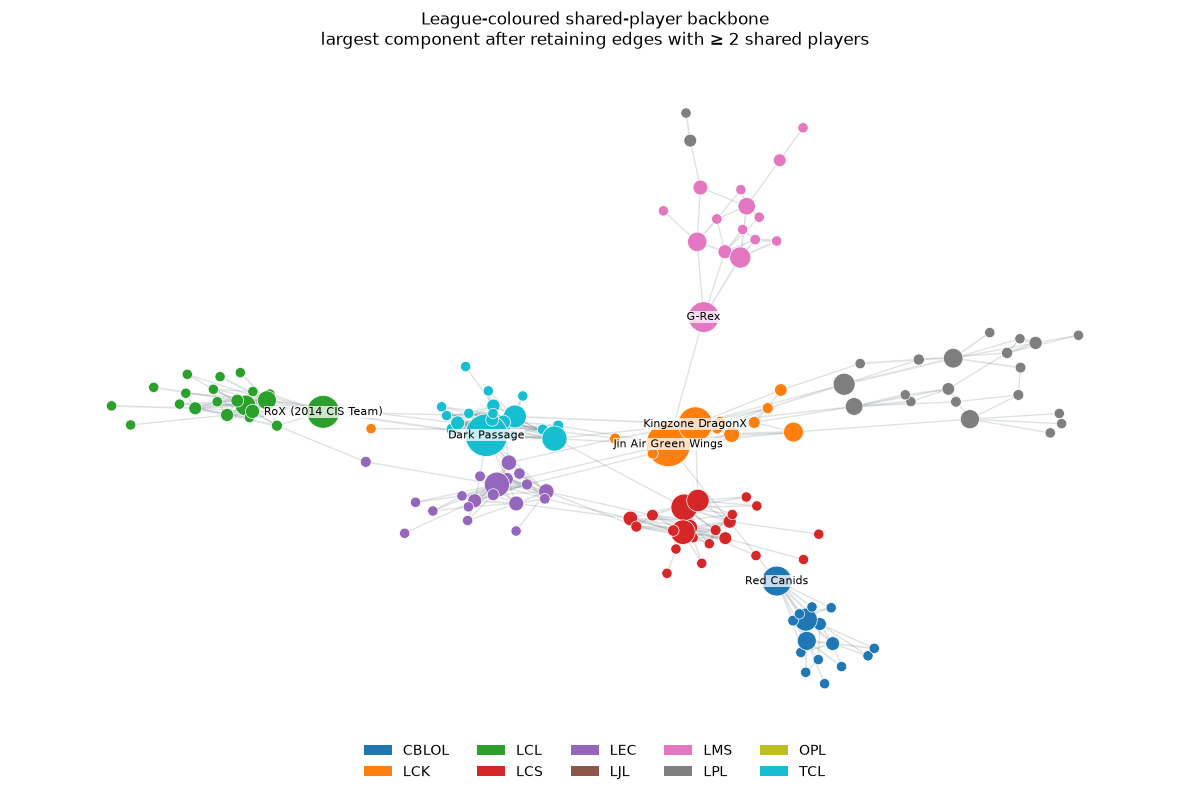

Displayed backbone: 148 teams and 392 edges. Full-network metrics still use all edges.


In [7]:
league_names = sorted(raw["leagues"].unique())
palette = plt.get_cmap("tab10")
league_colors = {league: palette(i) for i, league in enumerate(league_names)}
VISUAL_EDGE_THRESHOLD = 2

strong_edges = [
    (u, v) for u, v, attrs in team_graph.edges(data=True)
    if attrs["weight"] >= VISUAL_EDGE_THRESHOLD
]
league_backbone = team_graph.edge_subgraph(strong_edges).copy()
largest_backbone_nodes = max(nx.connected_components(league_backbone), key=len)
league_backbone = league_backbone.subgraph(largest_backbone_nodes).copy()

pos = nx.spring_layout(
    league_backbone, seed=SEED, weight="weight",
    k=1.6 / np.sqrt(league_backbone.number_of_nodes()), iterations=350,
)
backbone_betweenness = nx.betweenness_centrality(
    league_backbone, weight="distance", normalized=True
)
weights = np.array([attrs["weight"] for _, _, attrs in league_backbone.edges(data=True)])
label_nodes = sorted(
    league_backbone, key=lambda node: backbone_betweenness[node], reverse=True
)[:6]

fig, ax = plt.subplots(figsize=(12, 8))
nx.draw_networkx_edges(
    league_backbone, pos, ax=ax, alpha=0.18, edge_color="#52616B",
    width=0.5 + 2.5 * weights / weights.max(),
)
nx.draw_networkx_nodes(
    league_backbone, pos, ax=ax,
    node_size=[55 + 2200 * backbone_betweenness[node] for node in league_backbone],
    node_color=[league_colors[league_backbone.nodes[node]["league"]] for node in league_backbone],
    edgecolors="white", linewidths=0.5,
)
nx.draw_networkx_labels(
    league_backbone, pos,
    labels={node: league_backbone.nodes[node]["label"] for node in label_nodes},
    font_size=8, ax=ax,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 0.2},
)
ax.legend(
    handles=[Patch(facecolor=league_colors[league], label=league) for league in league_names],
    loc="lower center", bbox_to_anchor=(0.5, -0.07), ncol=5, frameon=False,
)
ax.set_title(
    "League-coloured shared-player backbone\n"
    f"largest component after retaining edges with ≥ {VISUAL_EDGE_THRESHOLD} shared players"
)
ax.axis("off")
plt.tight_layout()
plt.show()
print(
    f"Displayed backbone: {league_backbone.number_of_nodes()} teams and "
    f"{league_backbone.number_of_edges()} edges. Full-network metrics still use all edges."
)

### Focused player–team bipartite views

The full 2,273-node bipartite graph is too dense for a static report figure. These two deliberately limited views preserve the real player–team structure:

- The **LCK–LPL mobility corridor** contains the ten players with the most recorded LCK/LPL games among players who represented teams in both leagues.
- The **GBM ego network** shows one highly mobile player's complete recorded team history across four leagues.

Edges remain undirected affiliations; their widths represent recorded games, not transfer direction.


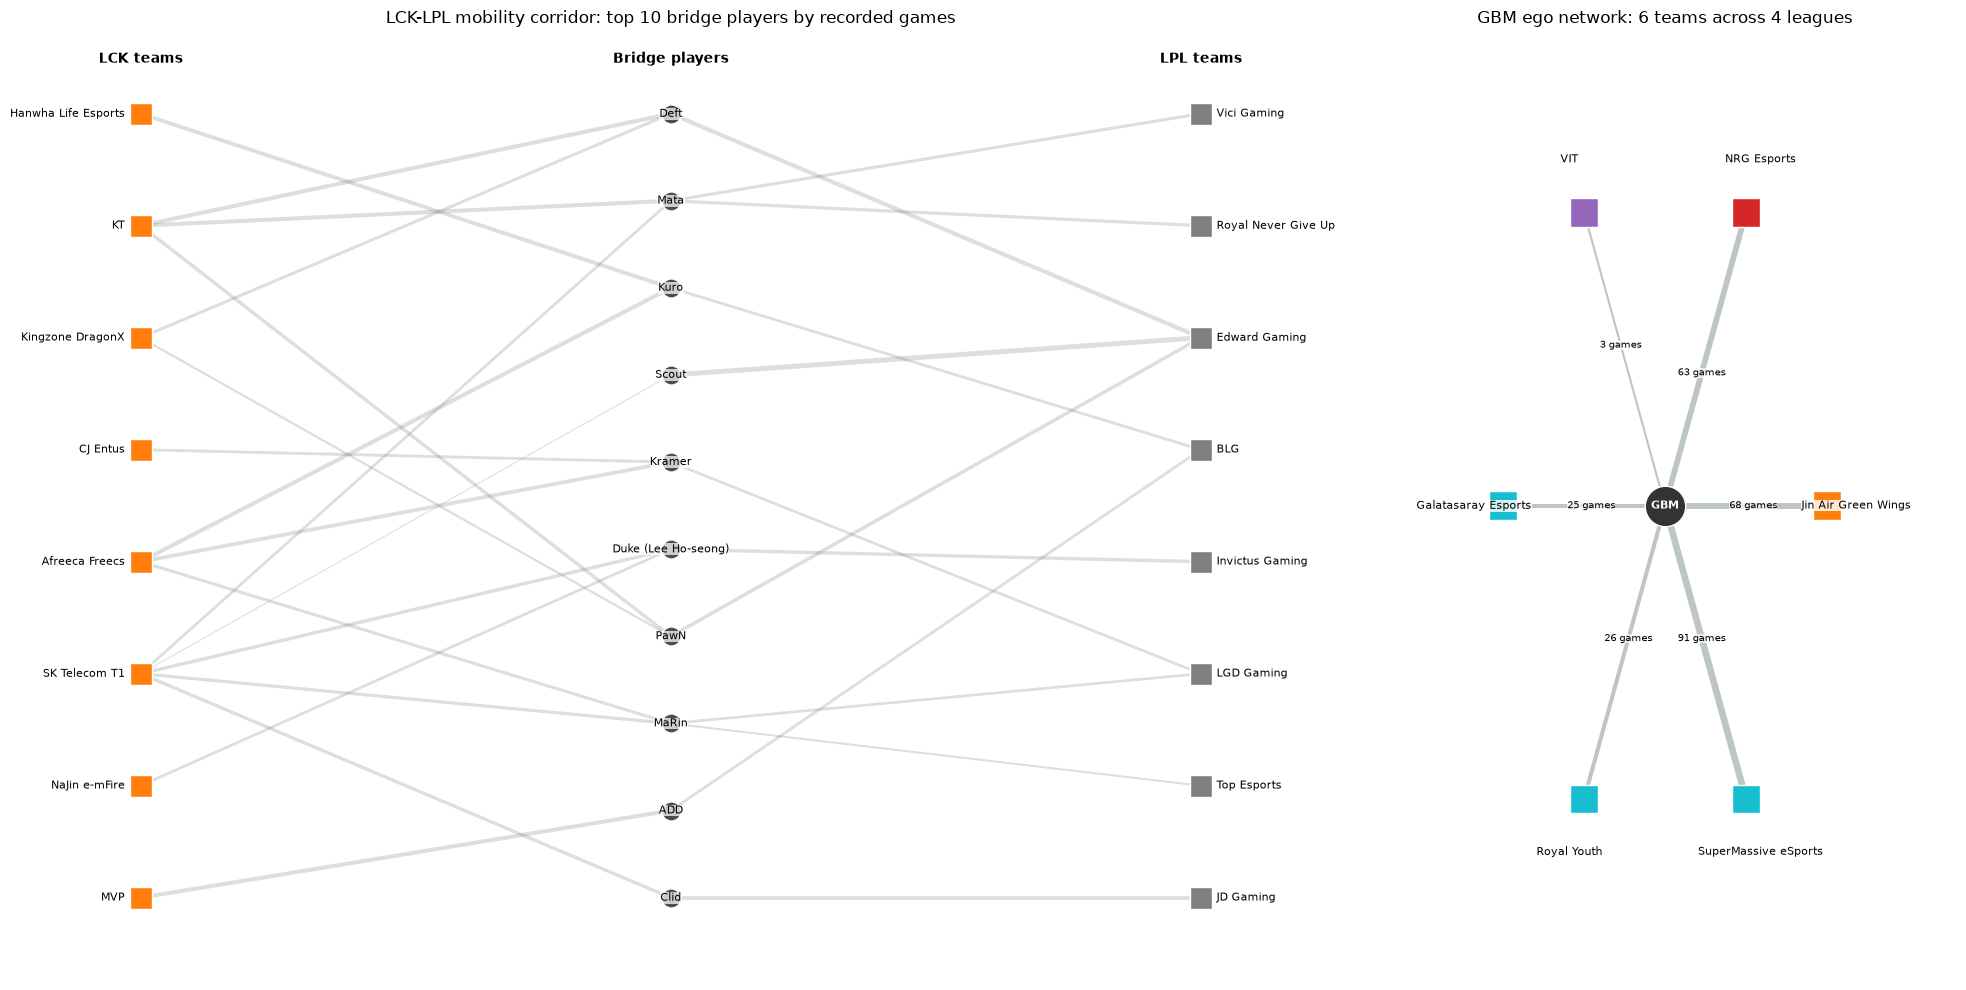

Focused LCK-LPL graph: 10 players, 16 teams, 29 affiliations.


In [8]:
FOCUSED_BRIDGE_PLAYERS = 10

lck_lpl_rows = []
for player_node, frame in edge_table.groupby("player_node", sort=True):
    relevant = frame[frame["leagues"].isin(["LCK", "LPL"])]
    if {"LCK", "LPL"}.issubset(set(relevant["leagues"])):
        lck_lpl_rows.append(
            {
                "player_node": player_node,
                "player_name": frame["player_name"].iloc[-1],
                "lck_lpl_games": relevant["games_total"].sum(),
            }
        )
focused_players = {
    row["player_node"]
    for row in sorted(lck_lpl_rows, key=lambda row: row["lck_lpl_games"], reverse=True)
    [:FOCUSED_BRIDGE_PLAYERS]
}
focused_teams = {
    team_node
    for player_node in focused_players
    for team_node in B.neighbors(player_node)
    if B.nodes[team_node]["league"] in {"LCK", "LPL"}
}
focused_bipartite = B.subgraph(focused_players | focused_teams).copy()

player_order = sorted(
    focused_players,
    key=lambda node: B.degree(node, weight="weight"),
    reverse=True,
)
player_y = dict(zip(player_order, np.linspace(1, -1, len(player_order))))

def ordered_team_positions(league):
    nodes = [node for node in focused_teams if B.nodes[node]["league"] == league]
    nodes.sort(key=lambda node: np.mean([player_y[p] for p in B.neighbors(node) if p in player_y]), reverse=True)
    return dict(zip(nodes, np.linspace(1, -1, len(nodes))))

lck_y = ordered_team_positions("LCK")
lpl_y = ordered_team_positions("LPL")
focused_pos = {
    **{node: (-1.35, y) for node, y in lck_y.items()},
    **{node: (0, y) for node, y in player_y.items()},
    **{node: (1.35, y) for node, y in lpl_y.items()},
}

fig, axes = plt.subplots(1, 2, figsize=(20, 10), gridspec_kw={"width_ratios": [2.2, 1]})
focused_weights = np.array([
    attrs["weight"] for _, _, attrs in focused_bipartite.edges(data=True)
])
nx.draw_networkx_edges(
    focused_bipartite, focused_pos, ax=axes[0], edge_color="#7F8C8D", alpha=0.28,
    width=0.6 + 3.0 * np.sqrt(focused_weights / focused_weights.max()),
)
nx.draw_networkx_nodes(
    focused_bipartite, focused_pos, ax=axes[0], nodelist=sorted(lck_y),
    node_shape="s", node_size=230, node_color=[league_colors["LCK"]], edgecolors="white",
)
nx.draw_networkx_nodes(
    focused_bipartite, focused_pos, ax=axes[0], nodelist=player_order,
    node_shape="o", node_size=190, node_color="#4D4D4D", edgecolors="white",
)
nx.draw_networkx_nodes(
    focused_bipartite, focused_pos, ax=axes[0], nodelist=sorted(lpl_y),
    node_shape="s", node_size=230, node_color=[league_colors["LPL"]], edgecolors="white",
)
for node, (x, y) in focused_pos.items():
    label = focused_bipartite.nodes[node]["label"]
    offset = -0.04 if x < 0 else 0.04 if x > 0 else 0
    axes[0].text(
        x + offset, y, label,
        ha="right" if x < 0 else "left" if x > 0 else "center",
        va="center", fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "pad": 0.15},
    )
axes[0].text(-1.35, 1.13, "LCK teams", ha="center", weight="bold")
axes[0].text(0, 1.13, "Bridge players", ha="center", weight="bold")
axes[0].text(1.35, 1.13, "LPL teams", ha="center", weight="bold")
axes[0].set_title("LCK-LPL mobility corridor: top 10 bridge players by recorded games")
axes[0].axis("off")

example_player = "player::gbm"
example_teams = sorted(B.neighbors(example_player), key=lambda node: B.nodes[node]["league"])
example_graph = B.subgraph({example_player, *example_teams}).copy()
angles = np.linspace(0, 2 * np.pi, len(example_teams), endpoint=False)
example_pos = {example_player: (0, 0)}
example_pos.update({node: (np.cos(angle), np.sin(angle)) for node, angle in zip(example_teams, angles)})
example_weights = np.array([
    attrs["weight"] for _, _, attrs in example_graph.edges(data=True)
])
nx.draw_networkx_edges(
    example_graph, example_pos, ax=axes[1], edge_color="#7F8C8D", alpha=0.5,
    width=0.8 + 4 * np.sqrt(example_weights / example_weights.max()),
)
nx.draw_networkx_nodes(
    example_graph, example_pos, ax=axes[1], nodelist=[example_player],
    node_size=850, node_color="#333333", edgecolors="white",
)
nx.draw_networkx_nodes(
    example_graph, example_pos, ax=axes[1], nodelist=example_teams,
    node_shape="s", node_size=430,
    node_color=[league_colors[B.nodes[node]["league"]] for node in example_teams],
    edgecolors="white",
)
nx.draw_networkx_labels(
    example_graph, example_pos, labels={example_player: B.nodes[example_player]["label"]},
    ax=axes[1], font_size=8, font_color="white", font_weight="bold",
)
example_team_label_pos = {
    node: (1.18 * example_pos[node][0], 1.18 * example_pos[node][1])
    for node in example_teams
}
nx.draw_networkx_labels(
    example_graph, example_team_label_pos,
    labels={node: B.nodes[node]["label"] for node in example_teams},
    ax=axes[1], font_size=8, font_color="black",
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.82, "pad": 0.15},
)
edge_game_labels = {
    (u, v): f"{int(attrs['weight'])} games"
    for u, v, attrs in example_graph.edges(data=True)
}
nx.draw_networkx_edge_labels(
    example_graph, example_pos, edge_labels=edge_game_labels, ax=axes[1],
    font_size=7, rotate=False, label_pos=0.55,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.7, "pad": 0.1},
)
axes[1].set_title("GBM ego network: 6 teams across 4 leagues")
axes[1].set_xlim(-1.8, 1.8)
axes[1].set_ylim(-1.4, 1.4)
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(
    f"Focused LCK-LPL graph: {len(focused_players)} players, "
    f"{len(focused_teams)} teams, {focused_bipartite.number_of_edges()} affiliations."
)


### LCK within-league player mobility graph

This focused bipartite graph keeps affiliations with at least 10 recorded games and players who represented at least two LCK team lineages. It therefore shows sustained **within-LCK mobility**, not every roster member. All included teams are labelled; only the most connected mobile players are labelled for readability.


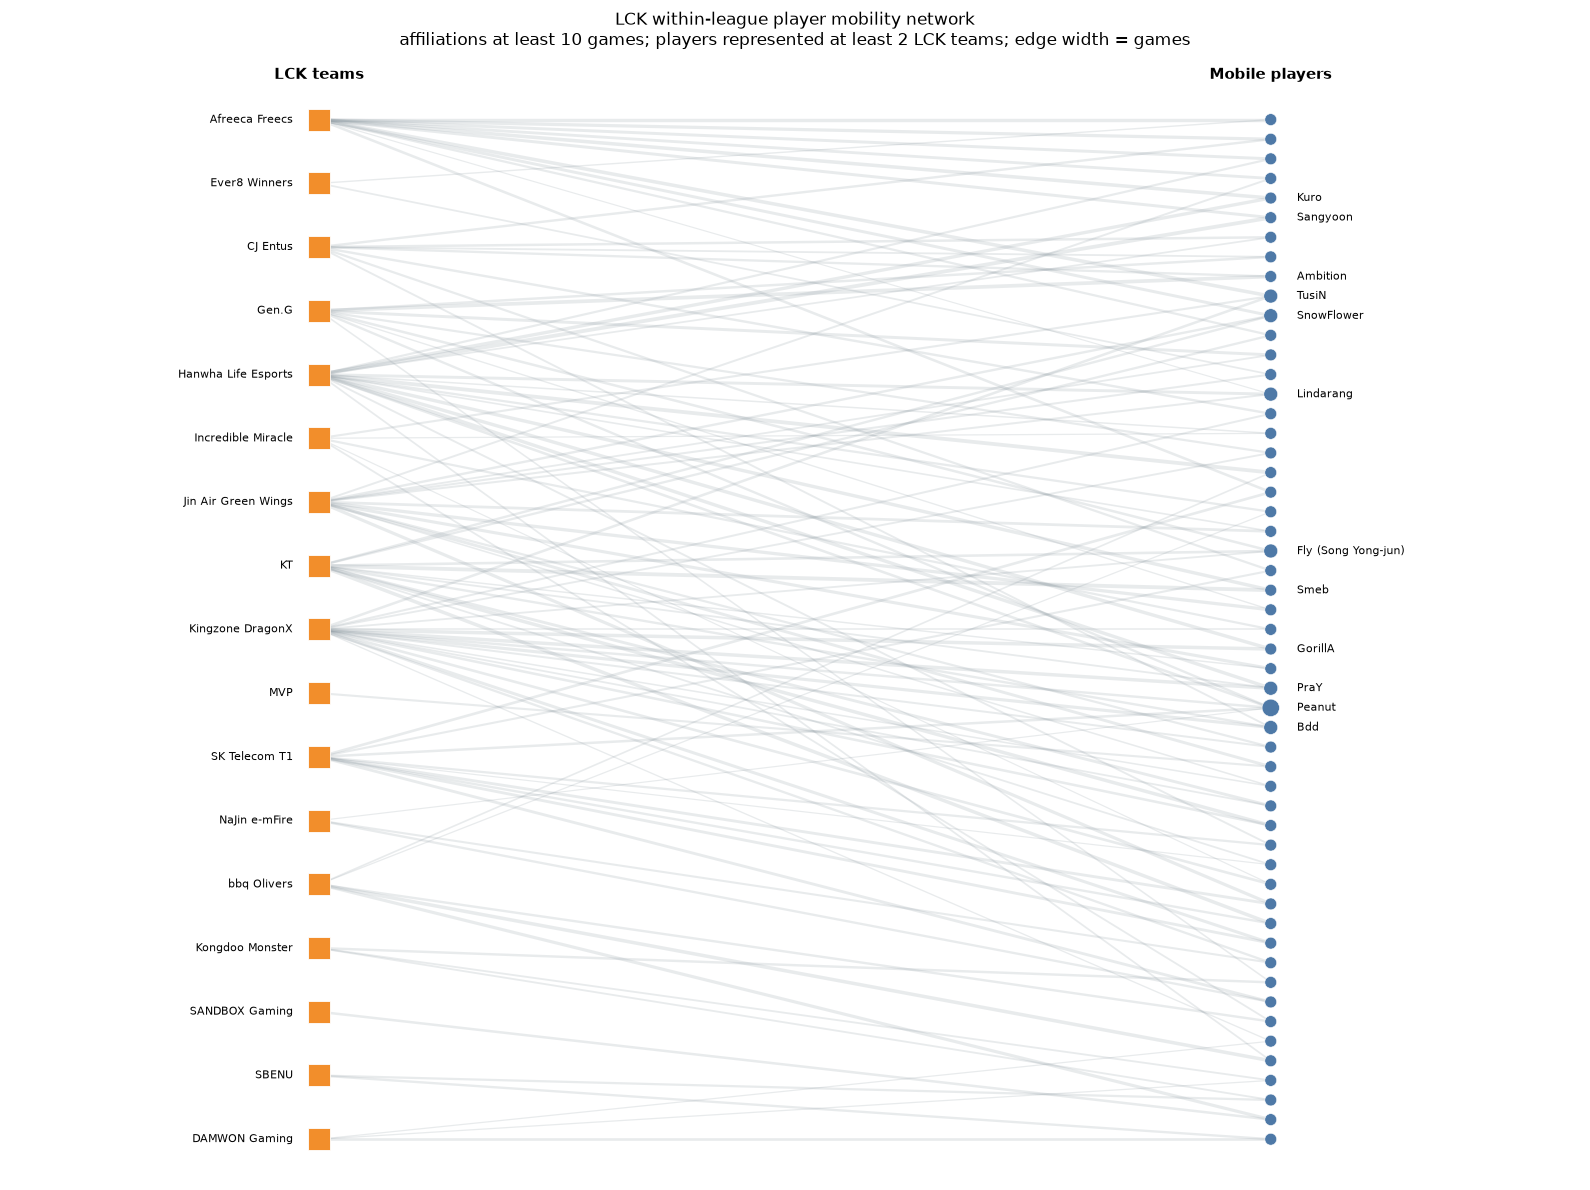

LCK mobility graph: 17 teams, 53 players, 115 affiliations.


,player,LCK_teams,recorded_games
0,Peanut,5,391.0
1,PraY,3,465.0
2,TusiN,3,392.0
3,SnowFlower,3,320.0
4,Bdd,3,304.0
5,Fly (Song Yong-jun),3,254.0
6,Lindarang,3,210.0
7,Smeb,2,473.0
8,GorillA,2,421.0
9,Kuro,2,418.0


In [9]:
LCK_MIN_GAMES = 10
LCK_PLAYER_LABELS = 12

lck_edges = edge_table[
    edge_table["leagues"].eq("LCK")
    & edge_table["games_total"].ge(LCK_MIN_GAMES)
].copy()
lck_team_counts = lck_edges.groupby("player_node")["team_node"].nunique()
lck_mobile_players = set(lck_team_counts[lck_team_counts >= 2].index)
lck_edges = lck_edges[lck_edges["player_node"].isin(lck_mobile_players)]
lck_mobile_teams = set(lck_edges["team_node"])

lck_mobile_graph = nx.Graph(name="LCK within-league player mobility")
for row in lck_edges.itertuples(index=False):
    lck_mobile_graph.add_node(
        row.team_node, node_type="team", label=row.team_name
    )
    lck_mobile_graph.add_node(
        row.player_node, node_type="player", label=row.player_name
    )
    lck_mobile_graph.add_edge(
        row.team_node, row.player_node, weight=float(row.games_total)
    )

team_order = sorted(lck_mobile_teams, key=lambda node: lck_mobile_graph.nodes[node]["label"])
player_order = sorted(lck_mobile_players)
for _ in range(5):
    team_rank = {node: rank for rank, node in enumerate(team_order)}
    player_order.sort(
        key=lambda player: np.average(
            [team_rank[team] for team in lck_mobile_graph.neighbors(player)],
            weights=[lck_mobile_graph[player][team]["weight"] for team in lck_mobile_graph.neighbors(player)],
        )
    )
    player_rank = {node: rank for rank, node in enumerate(player_order)}
    team_order.sort(
        key=lambda team: np.average(
            [player_rank[player] for player in lck_mobile_graph.neighbors(team)],
            weights=[lck_mobile_graph[team][player]["weight"] for player in lck_mobile_graph.neighbors(team)],
        )
    )

lck_pos = {
    **{node: (-1, y) for node, y in zip(team_order, np.linspace(1, -1, len(team_order)))},
    **{node: (1, y) for node, y in zip(player_order, np.linspace(1, -1, len(player_order)))},
}
player_label_nodes = sorted(
    lck_mobile_players,
    key=lambda node: (
        lck_mobile_graph.degree(node),
        lck_mobile_graph.degree(node, weight="weight"),
    ),
    reverse=True,
)[:LCK_PLAYER_LABELS]
edge_weights = np.array([
    attrs["weight"] for _, _, attrs in lck_mobile_graph.edges(data=True)
])

fig, ax = plt.subplots(figsize=(16, 12))
nx.draw_networkx_edges(
    lck_mobile_graph, lck_pos, ax=ax, edge_color="#84929A", alpha=0.18,
    width=0.35 + 2.4 * np.sqrt(edge_weights / edge_weights.max()),
)
nx.draw_networkx_nodes(
    lck_mobile_graph, lck_pos, ax=ax, nodelist=team_order,
    node_shape="s", node_size=250, node_color="#F28E2B",
    edgecolors="white", linewidths=0.6,
)
nx.draw_networkx_nodes(
    lck_mobile_graph, lck_pos, ax=ax, nodelist=player_order,
    node_shape="o",
    node_size=[45 + 28 * (lck_mobile_graph.degree(node) - 1) for node in player_order],
    node_color="#4E79A7", edgecolors="white", linewidths=0.4,
)
for team in team_order:
    x, y = lck_pos[team]
    ax.text(
        x - 0.055, y, lck_mobile_graph.nodes[team]["label"],
        ha="right", va="center", fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 0.12},
    )
for player in player_label_nodes:
    x, y = lck_pos[player]
    ax.text(
        x + 0.055, y, lck_mobile_graph.nodes[player]["label"],
        ha="left", va="center", fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 0.12},
    )
ax.text(-1, 1.08, "LCK teams", ha="center", fontsize=11, weight="bold")
ax.text(1, 1.08, "Mobile players", ha="center", fontsize=11, weight="bold")
ax.set_title(
    "LCK within-league player mobility network\n"
    f"affiliations at least {LCK_MIN_GAMES} games; players represented at least 2 LCK teams; edge width = games"
)
ax.set_xlim(-1.65, 1.65)
ax.set_ylim(-1.08, 1.13)
ax.axis("off")
plt.tight_layout()
plt.show()

lck_mobile_player_summary = pd.DataFrame(
    {
        "player": lck_mobile_graph.nodes[player]["label"],
        "LCK_teams": lck_mobile_graph.degree(player),
        "recorded_games": lck_mobile_graph.degree(player, weight="weight"),
    }
    for player in player_label_nodes
)
print(
    f"LCK mobility graph: {len(lck_mobile_teams)} teams, {len(lck_mobile_players)} players, "
    f"{lck_mobile_graph.number_of_edges()} affiliations."
)
display(lck_mobile_player_summary)

## 5. League boundaries and bridge actors

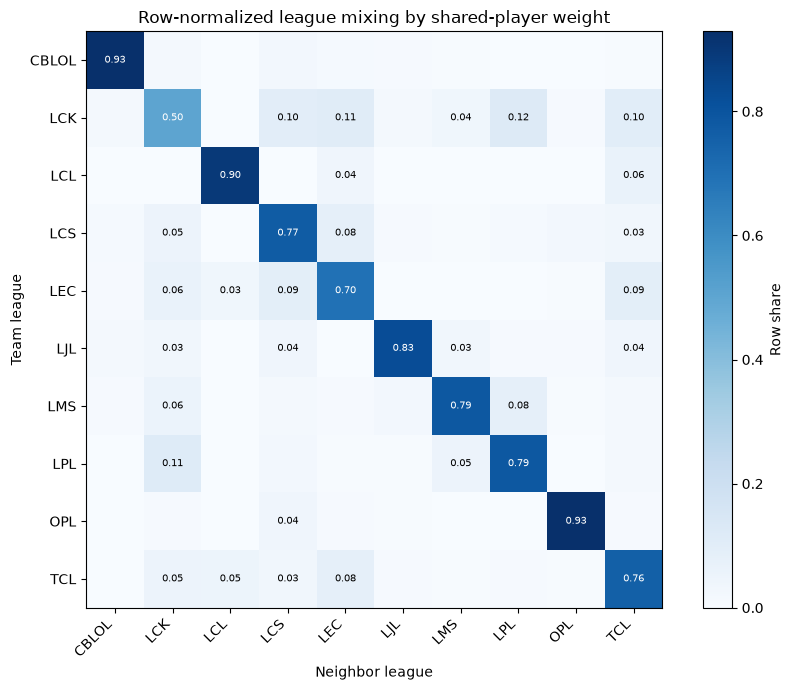

In [10]:
league_assortativity = nx.attribute_assortativity_coefficient(team_graph, "league")
group_assortativity = nx.attribute_assortativity_coefficient(team_graph, "display_group")
same_edges = [(u, v, d) for u, v, d in team_graph.edges(data=True)
              if team_graph.nodes[u]["league"] == team_graph.nodes[v]["league"]]
cross_edges = [(u, v, d) for u, v, d in team_graph.edges(data=True)
               if team_graph.nodes[u]["league"] != team_graph.nodes[v]["league"]]
total_weight = sum(d["weight"] for _, _, d in team_graph.edges(data=True))
same_weight = sum(d["weight"] for _, _, d in same_edges)

league_boundary_summary = pd.DataFrame(
    {
        "metric": [
            "League assortativity", "Major/minor assortativity",
            "Same-league edge share", "Cross-league edge share",
            "Weighted same-league share", "Weighted cross-league share",
        ],
        "value": [
            league_assortativity, group_assortativity,
            len(same_edges) / team_graph.number_of_edges(),
            len(cross_edges) / team_graph.number_of_edges(),
            same_weight / total_weight, 1 - same_weight / total_weight,
        ],
    }
)

league_mixing = pd.DataFrame(0.0, index=league_names, columns=league_names)
for u, v, attrs in team_graph.edges(data=True):
    lu, lv, weight = team_graph.nodes[u]["league"], team_graph.nodes[v]["league"], attrs["weight"]
    league_mixing.loc[lu, lv] += weight
    league_mixing.loc[lv, lu] += weight
normalized_league_mixing = league_mixing.div(league_mixing.sum(axis=1), axis=0).fillna(0)

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(normalized_league_mixing, cmap="Blues", vmin=0, vmax=normalized_league_mixing.to_numpy().max())
ax.set_xticks(range(len(league_names)), league_names, rotation=45, ha="right")
ax.set_yticks(range(len(league_names)), league_names)
for i in range(len(league_names)):
    for j in range(len(league_names)):
        value = normalized_league_mixing.iloc[i, j]
        if value >= 0.03:
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if value > 0.45 else "black")
ax.set_title("Row-normalized league mixing by shared-player weight")
ax.set_xlabel("Neighbor league")
ax.set_ylabel("Team league")
fig.colorbar(image, ax=ax, label="Row share")
plt.tight_layout()
plt.show()

strongest_cross_league = pd.DataFrame(
    {
        "team_a": team_graph.nodes[u]["label"],
        "league_a": team_graph.nodes[u]["league"],
        "team_b": team_graph.nodes[v]["label"],
        "league_b": team_graph.nodes[v]["league"],
        "shared_players": d["weight"],
    }
    for u, v, d in cross_edges
).sort_values(["shared_players", "team_a", "team_b"], ascending=[False, True, True]).head(20)

In [11]:
bridge_rows = []
for node in team_graph:
    neighbors = list(team_graph.neighbors(node))
    own_league = team_graph.nodes[node]["league"]
    neighbor_leagues = {team_graph.nodes[n]["league"] for n in neighbors}
    bridge_rows.append(
        {
            "team_node": node,
            "team_name": team_graph.nodes[node]["label"],
            "league": own_league,
            "group": team_graph.nodes[node]["display_group"],
            "degree": degree[node],
            "weighted_degree": weighted_degree[node],
            "betweenness": betweenness[node],
            "connected_leagues": len(neighbor_leagues),
            "cross_league_neighbors": sum(team_graph.nodes[n]["league"] != own_league for n in neighbors),
        }
    )
bridge_teams = (
    pd.DataFrame(bridge_rows)
      .sort_values(["betweenness", "cross_league_neighbors", "weighted_degree"], ascending=False)
      .head(20).reset_index(drop=True)
)

player_bridge_rows = []
for player_node, frame in edge_table.groupby("player_node", sort=True):
    leagues = split_values(frame["leagues"])
    raw_groups = set(split_values(frame["group"]))
    groups = sorted("minor" if value == "wildcard" else value for value in raw_groups)
    player_bridge_rows.append(
        {
            "player_node": player_node,
            "player_name": frame["player_name"].iloc[-1],
            "teams": frame["team_node"].nunique(),
            "leagues": len(leagues),
            "leagues_represented": ", ".join(leagues),
            "major_minor_bridge": {"major", "minor"}.issubset(groups),
            "total_games": frame["games_total"].sum(),
        }
    )
player_bridge_table = pd.DataFrame(player_bridge_rows)
top_player_league_bridges = (
    player_bridge_table.sort_values(["leagues", "teams", "total_games"], ascending=False)
                       .head(20).reset_index(drop=True)
)
major_minor_player_bridges = (
    player_bridge_table[player_bridge_table["major_minor_bridge"]]
      .sort_values(["leagues", "teams", "total_games"], ascending=False)
      .head(20).reset_index(drop=True)
)
print("Bridge team and bridge player tables are ready.")

Bridge team and bridge player tables are ready.


## 6. Community detection and comparison

Community structure is model-dependent, so five methods are compared on the team projection's giant component:

- **Louvain** and **greedy modularity** optimize modularity.
- **Label propagation** is a fast local-label baseline.
- **Leiden** refines Louvain-style communities to improve connectivity.
- **Infomap** is the random-walk-based method: it seeks groups that trap a random walker. Random walking is therefore an algorithmic idea here, not a separate quality score.

The partitions are evaluated with modularity, weighted coverage, median weighted conductance, and run-to-run ARI stability. NMI and ARI against league labels measure **alignment with leagues**, not ground-truth correctness.

In [12]:
giant_component_nodes = max(nx.connected_components(team_graph), key=len)
community_graph = team_graph.subgraph(giant_component_nodes).copy()
teams_outside_giant_component = team_graph.number_of_nodes() - community_graph.number_of_nodes()
ordered_nodes = sorted(community_graph)

igraph_node_index = {node: i for i, node in enumerate(ordered_nodes)}
igraph_edges = [
    (igraph_node_index[u], igraph_node_index[v])
    for u, v in community_graph.edges()
]
igraph_graph = ig.Graph(n=len(ordered_nodes), edges=igraph_edges, directed=False)
igraph_graph.vs["name"] = ordered_nodes
igraph_graph.es["weight"] = [
    float(attrs["weight"]) for _, _, attrs in community_graph.edges(data=True)
]

def normalize_partition(partition):
    groups = [set(group) for group in partition if group]
    assigned = set().union(*groups) if groups else set()
    groups.extend({node} for node in sorted(set(community_graph) - assigned))
    assert sum(map(len, groups)) == community_graph.number_of_nodes()
    assert len(set().union(*groups)) == community_graph.number_of_nodes()
    return groups

def igraph_partition(clustering):
    return normalize_partition(
        [{ordered_nodes[index] for index in group} for group in clustering]
    )

def run_community_method(method, seed):
    if method == "Louvain":
        return normalize_partition(
            nx.community.louvain_communities(
                community_graph, weight="weight", seed=seed
            )
        )
    if method == "Greedy modularity":
        return normalize_partition(
            nx.community.greedy_modularity_communities(
                community_graph, weight="weight"
            )
        )
    if method == "Label propagation":
        return normalize_partition(
            nx.community.asyn_lpa_communities(
                community_graph, weight="weight", seed=seed
            )
        )
    ig.set_random_number_generator(random.Random(seed))
    if method == "Leiden":
        return igraph_partition(
            igraph_graph.community_leiden(
                objective_function="modularity", weights="weight", n_iterations=-1
            )
        )
    if method == "Infomap":
        return igraph_partition(
            igraph_graph.community_infomap(edge_weights="weight", trials=20)
        )
    raise ValueError(f"Unknown community method: {method}")

def partition_membership(partition):
    assignment = {
        node: community_id
        for community_id, members in enumerate(partition)
        for node in members
    }
    return [assignment[node] for node in ordered_nodes]

def weighted_coverage(graph, partition):
    assignment = {
        node: community_id
        for community_id, members in enumerate(partition)
        for node in members
    }
    total = sum(attrs["weight"] for _, _, attrs in graph.edges(data=True))
    internal = sum(
        attrs["weight"] for u, v, attrs in graph.edges(data=True)
        if assignment[u] == assignment[v]
    )
    return internal / total

def median_conductance(graph, partition):
    values = [
        nx.conductance(graph, members, weight="weight")
        for members in partition
        if 0 < len(members) < graph.number_of_nodes()
    ]
    return float(np.median(values)) if values else np.nan

COMMUNITY_METHODS = [
    "Louvain", "Greedy modularity", "Label propagation", "Leiden", "Infomap"
]
COMMUNITY_RUNS = 5
method_runs = {
    method: [run_community_method(method, SEED + run) for run in range(COMMUNITY_RUNS)]
    for method in COMMUNITY_METHODS
}
community_partitions = {method: runs[0] for method, runs in method_runs.items()}

league_labels = [community_graph.nodes[node]["league"] for node in ordered_nodes]
quality_rows = []
for method, partition in community_partitions.items():
    membership = partition_membership(partition)
    run_memberships = [partition_membership(run) for run in method_runs[method]]
    stability_scores = [
        adjusted_rand_score(run_memberships[i], run_memberships[j])
        for i in range(COMMUNITY_RUNS)
        for j in range(i + 1, COMMUNITY_RUNS)
    ]
    quality_rows.append(
        {
            "method": method,
            "communities": len(partition),
            "modularity": nx.community.modularity(
                community_graph, partition, weight="weight"
            ),
            "weighted_coverage": weighted_coverage(community_graph, partition),
            "median_conductance": median_conductance(community_graph, partition),
            "league_nmi": normalized_mutual_info_score(league_labels, membership),
            "league_ari": adjusted_rand_score(league_labels, membership),
            "stability_ari": np.mean(stability_scores),
            "largest_community_share": max(map(len, partition)) / len(ordered_nodes),
        }
    )

community_method_comparison = (
    pd.DataFrame(quality_rows)
      .sort_values(["modularity", "stability_ari"], ascending=False)
      .reset_index(drop=True)
)

pairwise_method_nmi = pd.DataFrame(
    index=COMMUNITY_METHODS, columns=COMMUNITY_METHODS, dtype=float
)
pairwise_method_ari = pairwise_method_nmi.copy()
for method_a in COMMUNITY_METHODS:
    membership_a = partition_membership(community_partitions[method_a])
    for method_b in COMMUNITY_METHODS:
        membership_b = partition_membership(community_partitions[method_b])
        pairwise_method_nmi.loc[method_a, method_b] = normalized_mutual_info_score(
            membership_a, membership_b
        )
        pairwise_method_ari.loc[method_a, method_b] = adjusted_rand_score(
            membership_a, membership_b
        )

community_method = community_method_comparison.iloc[0]["method"]
communities = community_partitions[community_method]
community_assignment = {
    node: community_id
    for community_id, members in enumerate(communities, start=1)
    for node in members
}
community_modularity = nx.community.modularity(
    community_graph, communities, weight="weight"
)
community_sizes = pd.DataFrame(
    {"community": range(1, len(communities) + 1), "teams": [len(group) for group in communities]}
).sort_values("teams", ascending=False)

community_league_rows = []
for community_id, members in enumerate(communities, start=1):
    counts = pd.Series([community_graph.nodes[node]["league"] for node in members]).value_counts()
    for league, count in counts.items():
        community_league_rows.append(
            {"community": community_id, "league": league, "teams": count, "share": count / len(members)}
        )
community_league_composition = pd.DataFrame(community_league_rows)

community_summary = pd.DataFrame(
    {
        "selected_method": [community_method],
        "giant_component_nodes": [community_graph.number_of_nodes()],
        "teams_outside_giant_component": [teams_outside_giant_component],
        "communities": [len(communities)],
        "modularity": [community_modularity],
    }
)

display(community_method_comparison.round(4))
display(pairwise_method_nmi.round(3))
display(pairwise_method_ari.round(3))
print(
    f"Selected {community_method} for downstream display because it had the highest "
    "modularity in the comparison table. League NMI/ARI are external-alignment measures, "
    "not proof that leagues are the uniquely correct communities."
)

,method,communities,modularity,weighted_coverage,median_conductance,league_nmi,league_ari,stability_ari,largest_community_share
0,Louvain,9,0.6767,0.8054,0.2078,0.9198,0.8495,1.0000,0.1930
1,Greedy modularity,9,0.6767,0.8054,0.2078,0.9198,0.8495,1.0000,0.1930
2,Leiden,9,0.6767,0.8054,0.2078,0.9198,0.8495,0.9957,0.1930
3,Label propagation,11,0.6755,0.8041,0.2254,0.9124,0.8294,0.8544,0.1974
4,Infomap,13,0.6703,0.7838,0.2254,0.9224,0.8923,1.0000,0.1272


,Louvain,Greedy modularity,Label propagation,Leiden,Infomap
Louvain,1.000,1.000,0.976,1.000,0.950
Greedy modularity,1.000,1.000,0.976,1.000,0.950
Label propagation,0.976,0.976,1.000,0.976,0.958
Leiden,1.000,1.000,0.976,1.000,0.950
Infomap,0.950,0.950,0.958,0.950,1.000


,Louvain,Greedy modularity,Label propagation,Leiden,Infomap
Louvain,1.000,1.000,0.969,1.000,0.880
Greedy modularity,1.000,1.000,0.969,1.000,0.880
Label propagation,0.969,0.969,1.000,0.969,0.888
Leiden,1.000,1.000,0.969,1.000,0.880
Infomap,0.880,0.880,0.888,0.880,1.000


Selected Louvain for downstream display because it had the highest modularity in the comparison table. League NMI/ARI are external-alignment measures, not proof that leagues are the uniquely correct communities.


### Community comparison visuals

Higher modularity and weighted coverage indicate more within-community structure; lower conductance indicates cleaner separation. NMI/ARI show how closely the detected partition resembles league membership. The network map uses the selected method and only the largest strong-edge backbone for legibility; all reported metrics still use the full giant component.

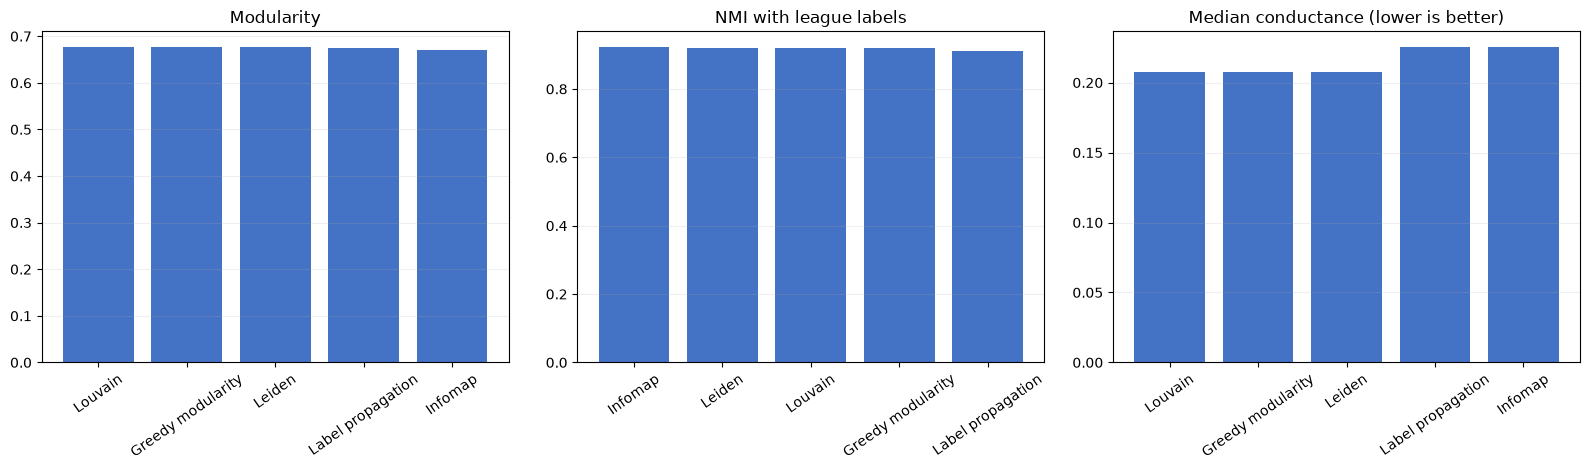

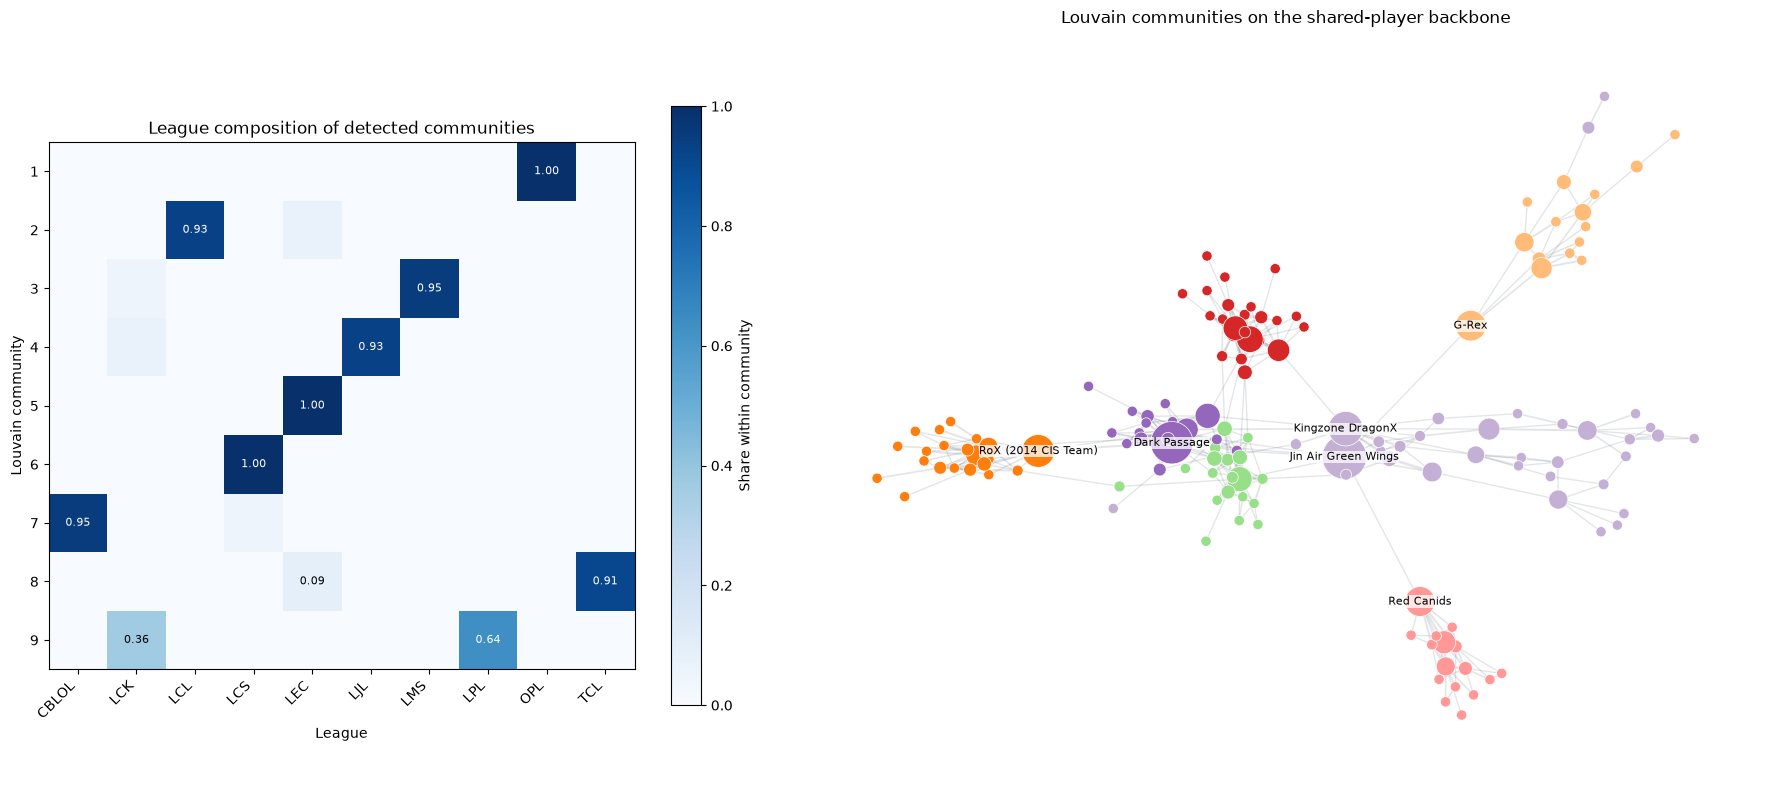

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
plot_specs = [
    ("modularity", "Modularity", True),
    ("league_nmi", "NMI with league labels", True),
    ("median_conductance", "Median conductance (lower is better)", False),
]
for ax, (column, title, higher_is_better) in zip(axes, plot_specs):
    frame = community_method_comparison.sort_values(column, ascending=not higher_is_better)
    ax.bar(frame["method"], frame[column], color="#4472C4")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

selected_backbone = community_graph.edge_subgraph([
    (u, v) for u, v, attrs in community_graph.edges(data=True)
    if attrs["weight"] >= VISUAL_EDGE_THRESHOLD
]).copy()
selected_backbone = selected_backbone.subgraph(
    max(nx.connected_components(selected_backbone), key=len)
).copy()
selected_pos = nx.spring_layout(
    selected_backbone, seed=SEED, weight="weight",
    k=1.7 / np.sqrt(selected_backbone.number_of_nodes()), iterations=400,
)
selected_betweenness = nx.betweenness_centrality(
    selected_backbone, weight="distance", normalized=True
)
selected_labels = sorted(
    selected_backbone, key=lambda node: selected_betweenness[node], reverse=True
)[:6]
community_palette = plt.get_cmap("tab20")

composition_matrix = (
    community_league_composition.pivot(index="community", columns="league", values="share")
                                .fillna(0)
                                .reindex(columns=league_names, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), gridspec_kw={"width_ratios": [1, 1.35]})
image = axes[0].imshow(composition_matrix, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(range(len(composition_matrix.columns)), composition_matrix.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(composition_matrix.index)), composition_matrix.index)
axes[0].set_xlabel("League")
axes[0].set_ylabel(f"{community_method} community")
axes[0].set_title("League composition of detected communities")
for row in range(composition_matrix.shape[0]):
    for column in range(composition_matrix.shape[1]):
        value = composition_matrix.iloc[row, column]
        if value >= 0.08:
            axes[0].text(column, row, f"{value:.2f}", ha="center", va="center", fontsize=8,
                         color="white" if value > 0.55 else "black")
fig.colorbar(image, ax=axes[0], label="Share within community", shrink=0.8)

edge_weights = np.array([
    attrs["weight"] for _, _, attrs in selected_backbone.edges(data=True)
])
nx.draw_networkx_edges(
    selected_backbone, selected_pos, ax=axes[1], alpha=0.16, edge_color="#52616B",
    width=0.5 + 2.4 * edge_weights / edge_weights.max(),
)
nx.draw_networkx_nodes(
    selected_backbone, selected_pos, ax=axes[1],
    node_size=[55 + 2200 * selected_betweenness[node] for node in selected_backbone],
    node_color=[community_palette(community_assignment[node] % 20) for node in selected_backbone],
    edgecolors="white", linewidths=0.5,
)
nx.draw_networkx_labels(
    selected_backbone, selected_pos, ax=axes[1],
    labels={node: selected_backbone.nodes[node]["label"] for node in selected_labels},
    font_size=8,
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 0.2},
)
axes[1].set_title(f"{community_method} communities on the shared-player backbone")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 7. Network position and performance

Team match and win totals are approximated by dividing player-level sums by five. Total games mainly measure exposure and longevity, not success.

In [14]:
team_performance = (
    raw.groupby("team_node", as_index=False, sort=True)
       .agg(
           team_name=("team_name", "last"),
           league=("leagues", join_values),
           raw_group=("group", join_values),
           domestic_games_player_sum=("games_domestic", "sum"),
           domestic_wins_player_sum=("wins_domestic", "sum"),
           international_games_player_sum=("games_international", "sum"),
           international_wins_player_sum=("wins_international", "sum"),
           active_year_list=("active_years", split_years),
       )
)
team_performance["group"] = team_performance["raw_group"].replace({"wildcard": "minor"})
team_performance["active_year_count"] = team_performance["active_year_list"].map(len)
team_performance["domestic_games"] = team_performance["domestic_games_player_sum"] / 5
team_performance["domestic_wins"] = team_performance["domestic_wins_player_sum"] / 5
team_performance["domestic_win_rate"] = team_performance["domestic_wins"].div(
    team_performance["domestic_games"].replace(0, np.nan)
)
team_performance["international_games"] = team_performance["international_games_player_sum"] / 5
team_performance["international_wins"] = team_performance["international_wins_player_sum"] / 5
team_performance["international_participation"] = team_performance["international_games_player_sum"] > 0
team_performance["international_games_per_active_year"] = (
    team_performance["international_games"]
    .div(team_performance["active_year_count"].replace(0, np.nan))
)
team_performance["international_win_rate"] = team_performance["international_wins"].div(
    team_performance["international_games"].replace(0, np.nan)
)

analysis_table = team_centrality.merge(
    team_performance[
        ["team_node", "domestic_games", "domestic_win_rate", "active_year_count",
         "international_participation", "international_games",
         "international_games_per_active_year", "international_win_rate"]
    ],
    on="team_node", how="left", validate="one_to_one",
)
analysis_table = analysis_table.merge(
    pd.DataFrame(bridge_rows)[["team_node", "cross_league_neighbors", "connected_leagues"]],
    on="team_node", how="left", validate="one_to_one",
)
active_year_denominator = analysis_table["active_year_count"].where(
    analysis_table["active_year_count"].notna() & analysis_table["active_year_count"].gt(0)
)
analysis_table["degree_per_active_year"] = analysis_table["degree"].div(active_year_denominator)
analysis_table["weighted_degree_per_active_year"] = (
    analysis_table["weighted_degree"].div(active_year_denominator)
)
analysis_table["cross_league_neighbors_per_active_year"] = (
    analysis_table["cross_league_neighbors"].div(active_year_denominator)
)

analysis_columns = [
    "team_name", "league", "group", "degree", "degree_per_active_year",
    "weighted_degree", "weighted_degree_per_active_year", "betweenness", "eigenvector",
    "cross_league_neighbors", "cross_league_neighbors_per_active_year", "connected_leagues",
    "domestic_games", "domestic_win_rate", "active_year_count",
    "international_participation", "international_games_per_active_year", "international_win_rate",
]
team_analysis_output = (
    analysis_table.sort_values(["betweenness", "weighted_degree"], ascending=False)[analysis_columns]
                  .reset_index(drop=True)
)
print(f"Team-level analysis table: {len(team_analysis_output):,} teams.")
display(team_analysis_output.head(20).round(4))

Team-level analysis table: 244 teams.


,team_name,league,group,degree,degree_per_active_year,weighted_degree,weighted_degree_per_active_year,betweenness,eigenvector,cross_league_neighbors,cross_league_neighbors_per_active_year,connected_leagues,domestic_games,domestic_win_rate,active_year_count,international_participation,international_games_per_active_year,international_win_rate
0,Dark Passage,TCL,minor,44,8.8000,105,21.0000,0.2390,0.4121,27,5.4000,8,267.0,0.4981,5,False,0.0000,NaN
1,RoX (2014 CIS Team),LCL,minor,26,5.2000,54,10.8000,0.1677,0.1565,7,1.4000,3,185.0,0.4595,5,False,0.0000,NaN
2,Jin Air Green Wings,LCK,major,28,5.6000,42,8.4000,0.1195,0.0902,19,3.8000,8,428.0,0.3762,5,False,0.0000,NaN
3,Echo Fox,LCS,major,32,8.0000,76,19.0000,0.0959,0.1060,9,2.2500,5,242.0,0.3719,4,False,0.0000,NaN
4,Kingzone DragonX,LCK,major,29,7.2500,49,12.2500,0.0823,0.0772,19,4.7500,7,375.0,0.5787,4,True,6.7500,0.5926
5,Red Canids,CBLOL,minor,19,4.7500,36,9.0000,0.0818,0.0212,7,1.7500,5,135.0,0.5259,4,True,1.5000,0.6667
6,Dignitas,LCS,major,30,10.0000,52,17.3333,0.0800,0.0951,14,4.6667,7,215.0,0.4465,3,False,0.0000,NaN
7,YouthCrew Esports,TCL,minor,31,7.7500,56,14.0000,0.0779,0.2289,17,4.2500,7,187.0,0.4599,4,False,0.0000,NaN
8,Dire Wolves,OPL,minor,17,3.4000,36,7.2000,0.0633,0.0158,6,1.2000,4,252.0,0.6151,5,True,4.2000,0.2857
9,CNB,CBLOL,minor,14,2.8000,32,6.4000,0.0589,0.0125,2,0.4000,3,203.0,0.4433,5,False,0.0000,NaN


### 7.1 Core-roster concentration and domestic performance

This analysis returns to the original player–team bipartite graph. For each team, the weights of its incident player edges are the players' recorded domestic games for that team. `core5_share` is the share of those player-games accumulated by the five most-used players. HHI is a second concentration measure; its inverse is the effective roster size.

This is a measure of **core-roster usage concentration**, not exact season-to-season retention. A one-year team will naturally look concentrated, so results are compared within activity-duration groups. Teams active for only one year are not treated as equally informative evidence about long-run roster stability.


In [15]:
# Measure how each team distributes domestic player-games across its players.
core_roster_rows = []
for team_node, frame in edge_table.groupby("team_node", sort=True):
    domestic_weights = frame["games_domestic"].to_numpy(dtype=float)
    domestic_shares = domestic_weights / domestic_weights.sum()
    core_roster_rows.append(
        {
            "team_node": team_node,
            "player_count": len(domestic_weights),
            "core5_share": np.sort(domestic_weights)[-5:].sum() / domestic_weights.sum(),
            "hhi": np.square(domestic_shares).sum(),
            "effective_roster_size": 1 / np.square(domestic_shares).sum(),
        }
    )

core_roster_analysis = pd.DataFrame(core_roster_rows).merge(
    team_performance[
        ["team_node", "team_name", "league", "group", "active_year_count", "domestic_win_rate"]
    ],
    on="team_node", how="left", validate="one_to_one",
)

def core_correlation_row(label, frame):
    core_result = spearmanr(frame["core5_share"], frame["domestic_win_rate"])
    hhi_result = spearmanr(frame["hhi"], frame["domestic_win_rate"])
    return {
        "scope": label, "teams": len(frame),
        "core5_rho": core_result.statistic, "core5_p": core_result.pvalue,
        "hhi_rho": hhi_result.statistic, "hhi_p": hhi_result.pvalue,
    }

core_duration_correlations = pd.DataFrame(
    [core_correlation_row("All teams", core_roster_analysis)]
    + [
        core_correlation_row(
            f"{years} active year{'s' if years > 1 else ''}",
            core_roster_analysis[core_roster_analysis["active_year_count"] == years],
        )
        for years in sorted(core_roster_analysis["active_year_count"].unique())
    ]
    + [
        core_correlation_row(
            "4-5 active years",
            core_roster_analysis[core_roster_analysis["active_year_count"] >= 4],
        )
    ]
)
duration_concentration_result = spearmanr(
    core_roster_analysis["core5_share"], core_roster_analysis["active_year_count"]
)

display(core_roster_analysis[
    ["core5_share", "hhi", "effective_roster_size", "player_count", "active_year_count", "domestic_win_rate"]
].describe().round(4))
display(core_duration_correlations.round(4))
print(
    "Core concentration is strongly confounded by activity duration: "
    f"rho={duration_concentration_result.statistic:.3f}. "
    "Interpret duration-stratified results rather than the pooled correlation."
)


,core5_share,hhi,effective_roster_size,player_count,active_year_count,domestic_win_rate
count,244.0000,244.0000,244.0000,244.0000,244.0000,244.0000
mean,0.7295,0.1319,8.9372,14.0451,2.2254,0.3937
std,0.1926,0.0466,4.2743,8.9641,1.5025,0.1822
min,0.2929,0.0313,5.0000,5.0000,1.0000,0.0000
25%,0.5945,0.0949,5.8601,7.0000,1.0000,0.2821
50%,0.7281,0.1301,7.6866,11.0000,2.0000,0.4070
75%,0.8948,0.1706,10.5328,19.2500,3.0000,0.5152
max,1.0000,0.2000,31.9389,57.0000,5.0000,0.7885


,scope,teams,core5_rho,core5_p,hhi_rho,hhi_p
0,All teams,244,-0.3789,0.0000,-0.3938,0.0000
1,1 active year,119,0.0178,0.8476,0.0024,0.9794
2,2 active years,48,0.1180,0.4246,0.1543,0.2951
3,3 active years,17,0.0049,0.9851,0.0319,0.9034
4,4 active years,23,0.4854,0.0189,0.5318,0.0090
5,5 active years,37,0.5756,0.0002,0.6332,0.0000
6,4-5 active years,60,0.4938,0.0001,0.5330,0.0000


Core concentration is strongly confounded by activity duration: rho=-0.772. Interpret duration-stratified results rather than the pooled correlation.


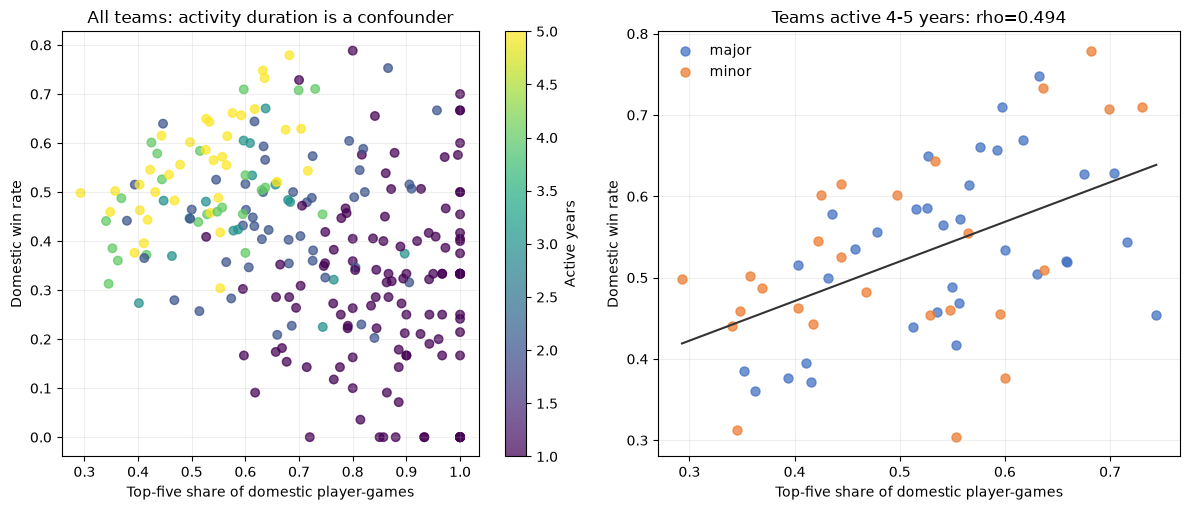

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

# All teams: colour reveals why activity duration must be handled explicitly.
scatter = axes[0].scatter(
    core_roster_analysis["core5_share"], core_roster_analysis["domestic_win_rate"],
    c=core_roster_analysis["active_year_count"], cmap="viridis", alpha=0.72, s=38,
)
axes[0].set(
    xlabel="Top-five share of domestic player-games", ylabel="Domestic win rate",
    title="All teams: activity duration is a confounder",
)
fig.colorbar(scatter, ax=axes[0], label="Active years")

# Long-lived teams provide a more meaningful comparison of persistent core use.
long_lived = core_roster_analysis[core_roster_analysis["active_year_count"] >= 4]
for group_name, frame in long_lived.groupby("group"):
    color = "#4472C4" if group_name == "major" else "#ED7D31"
    axes[1].scatter(
        frame["core5_share"], frame["domestic_win_rate"],
        color=color, label=group_name, alpha=0.75, s=42,
    )
trend = np.polyfit(long_lived["core5_share"], long_lived["domestic_win_rate"], 1)
trend_x = np.linspace(long_lived["core5_share"].min(), long_lived["core5_share"].max(), 100)
axes[1].plot(trend_x, np.polyval(trend, trend_x), color="#333333", linewidth=1.5)
long_result = spearmanr(long_lived["core5_share"], long_lived["domestic_win_rate"])
axes[1].set(
    xlabel="Top-five share of domestic player-games", ylabel="Domestic win rate",
    title=f"Teams active 4-5 years: rho={long_result.statistic:.3f}",
)
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### 7.2 Network position and recorded international participation

The following is a separate, secondary analysis on the derived team–team shared-player projection. It does not measure roster stability. It asks whether teams occupying bridge positions have more recorded international exposure.


In [17]:
raw_network_measures = [
    "degree", "weighted_degree", "betweenness", "eigenvector",
    "cross_league_neighbors", "connected_leagues",
]
adjusted_network_measures = [
    "degree_per_active_year", "weighted_degree_per_active_year",
    "cross_league_neighbors_per_active_year",
]
network_measures = raw_network_measures + adjusted_network_measures
outcomes = [
    "domestic_win_rate", "international_games_per_active_year",
    "international_win_rate", "active_year_count",
]
scopes = {
    "all": analysis_table,
    "major": analysis_table[analysis_table["group"] == "major"],
    "minor": analysis_table[analysis_table["group"] == "minor"],
}

def spearman_values(frame, variable_x, variable_y):
    valid = frame[[variable_x, variable_y]].dropna()
    if len(valid) >= 3 and valid[variable_x].nunique() > 1 and valid[variable_y].nunique() > 1:
        result = spearmanr(valid[variable_x], valid[variable_y])
        return len(valid), result.statistic, result.pvalue
    return len(valid), np.nan, np.nan

correlation_rows = []
for scope_name, frame in scopes.items():
    for measure in network_measures:
        for outcome in outcomes:
            sample_size, rho, p_value = spearman_values(frame, measure, outcome)
            correlation_rows.append(
                {"group": scope_name, "network_measure": measure, "outcome": outcome,
                 "n": sample_size, "spearman_rho": rho, "p_value": p_value}
            )
network_performance_correlations = pd.DataFrame(correlation_rows)

focused_relationships = [
    ("degree_per_active_year", "domestic_win_rate"),
    ("weighted_degree_per_active_year", "domestic_win_rate"),
    ("betweenness", "international_games_per_active_year"),
    ("cross_league_neighbors_per_active_year", "international_games_per_active_year"),
    ("connected_leagues", "international_games_per_active_year"),
] + [("active_year_count", measure) for measure in raw_network_measures]

focused_rows = []
for scope_name, frame in scopes.items():
    for variable_x, variable_y in focused_relationships:
        sample_size, rho, p_value = spearman_values(frame, variable_x, variable_y)
        focused_rows.append(
            {"group": scope_name, "variable_x": variable_x, "variable_y": variable_y,
             "n": sample_size, "spearman_rho": rho, "p_value": p_value}
        )
focused_correlations = pd.DataFrame(focused_rows)

comparison_measures = raw_network_measures + adjusted_network_measures
comparison_rows = []
for scope_name, frame in scopes.items():
    for measure in comparison_measures:
        no_participation = frame.loc[~frame["international_participation"], measure].dropna()
        participation = frame.loc[frame["international_participation"], measure].dropna()
        if len(no_participation) >= 2 and len(participation) >= 2:
            test = mannwhitneyu(participation, no_participation, alternative="two-sided", method="auto")
            u_value, p_value = test.statistic, test.pvalue
        else:
            u_value, p_value = np.nan, np.nan
        comparison_rows.append(
            {
                "group": scope_name, "network_measure": measure,
                "n_participation": len(participation), "median_participation": participation.median(),
                "n_no_participation": len(no_participation),
                "median_no_participation": no_participation.median(),
                "mann_whitney_u": u_value, "p_value": p_value,
            }
        )
international_participation_comparison = pd.DataFrame(comparison_rows)

compact_measures = [
    "degree", "degree_per_active_year", "weighted_degree",
    "weighted_degree_per_active_year", "betweenness", "cross_league_neighbors",
    "cross_league_neighbors_per_active_year", "connected_leagues",
    "domestic_win_rate", "international_games_per_active_year",
]
compact_rows = []
for participation, frame in analysis_table.groupby("international_participation", sort=True):
    row = {
        "recorded_international_participation": "Yes" if participation else "No",
        "sample_size": len(frame),
    }
    row.update({measure: frame[measure].median() for measure in compact_measures})
    compact_rows.append(row)
compact_insight_table = pd.DataFrame(compact_rows)

display(focused_correlations.round(4))
print("The complete correlation results remain available in network_performance_correlations.")

,group,variable_x,variable_y,n,spearman_rho,p_value
0,all,degree_per_active_year,domestic_win_rate,244,0.0720,0.2628
1,all,weighted_degree_per_active_year,domestic_win_rate,244,0.1664,0.0092
2,all,betweenness,international_games_per_active_year,244,0.3906,0.0000
3,all,cross_league_neighbors_per_active_year,international_games_per_active_year,244,0.2600,0.0000
4,all,connected_leagues,international_games_per_active_year,244,0.3743,0.0000
5,all,active_year_count,degree,244,0.7479,0.0000
6,all,active_year_count,weighted_degree,244,0.7654,0.0000
7,all,active_year_count,betweenness,244,0.7879,0.0000
8,all,active_year_count,eigenvector,244,0.5078,0.0000
9,all,active_year_count,cross_league_neighbors,244,0.6519,0.0000


The complete correlation results remain available in network_performance_correlations.


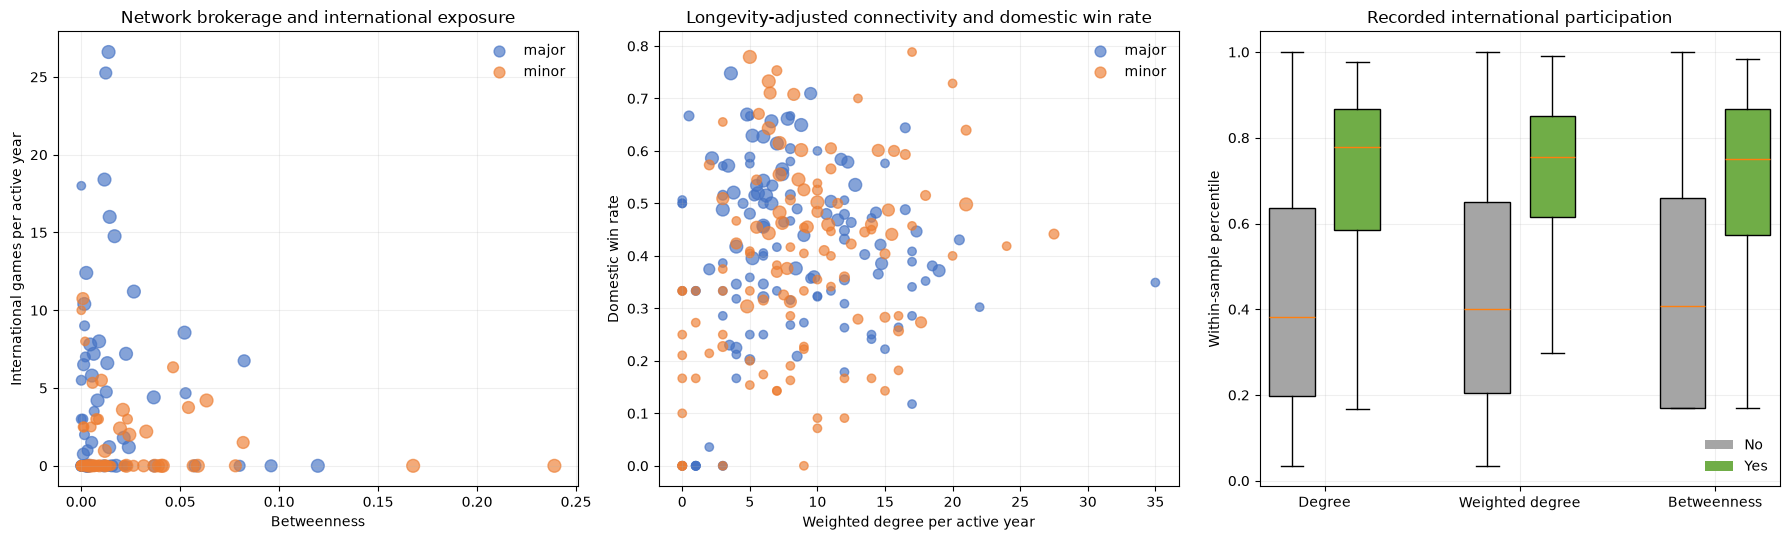

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for group_name, frame in analysis_table.groupby("group"):
    color = "#4472C4" if group_name == "major" else "#ED7D31"
    axes[0].scatter(frame["betweenness"], frame["international_games_per_active_year"],
                    s=25 + 12 * frame["active_year_count"], alpha=0.65, label=group_name, color=color)
    axes[1].scatter(frame["weighted_degree_per_active_year"], frame["domestic_win_rate"],
                    s=25 + 12 * frame["active_year_count"], alpha=0.65, label=group_name, color=color)
axes[0].set(xlabel="Betweenness", ylabel="International games per active year",
            title="Network brokerage and international exposure")
axes[1].set(xlabel="Weighted degree per active year", ylabel="Domestic win rate",
            title="Longevity-adjusted connectivity and domestic win rate")
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)

box_measures = ["degree", "weighted_degree", "betweenness"]
positions, data, colors, labels = [], [], [], []
for i, measure in enumerate(box_measures):
    ranked = analysis_table[measure].rank(pct=True)
    for j, flag in enumerate([False, True]):
        positions.append(i * 3 + j + 1)
        data.append(ranked[analysis_table["international_participation"] == flag].dropna())
        colors.append("#A5A5A5" if not flag else "#70AD47")
        labels.append("No" if not flag else "Yes")
box = axes[2].boxplot(data, positions=positions, widths=0.7, patch_artist=True, showfliers=False)
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
axes[2].set_xticks([1.5, 4.5, 7.5], ["Degree", "Weighted degree", "Betweenness"])
axes[2].set(ylabel="Within-sample percentile", title="Recorded international participation")
axes[2].legend(handles=[Patch(facecolor="#A5A5A5", label="No"), Patch(facecolor="#70AD47", label="Yes")],
               frameon=False)
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 8. Edge-threshold sensitivity

This is a sensitivity check, not a node-removal robustness experiment. It asks whether the bipartite graph's broad connectivity changes when short player-team affiliations are excluded.

In [19]:
MIN_GAMES_THRESHOLDS = [1, 5, 10]
threshold_rows = []
for threshold in MIN_GAMES_THRESHOLDS:
    kept = edge_table[edge_table["games_total"] >= threshold]
    graph = nx.Graph()
    graph.add_edges_from(kept[["player_node", "team_node"]].itertuples(index=False, name=None))
    players = set(kept["player_node"])
    teams = set(kept["team_node"])
    component_sizes = sorted((len(c) for c in nx.connected_components(graph)), reverse=True)
    threshold_rows.append(
        {
            "minimum_games": threshold,
            "nodes": graph.number_of_nodes(),
            "edges": graph.number_of_edges(),
            "components": len(component_sizes),
            "giant_component_share": component_sizes[0] / graph.number_of_nodes(),
            "density": bipartite.density(graph, players) if players and teams else np.nan,
        }
    )
edge_threshold_sensitivity = pd.DataFrame(threshold_rows)
display(edge_threshold_sensitivity.round(5))

,minimum_games,nodes,edges,components,giant_component_share,density
0,1,2273,3427,17,0.94897,0.00692
1,5,1943,2893,14,0.95677,0.00746
2,10,1710,2514,13,0.96316,0.00795


## 9. Final output tables

In [20]:
final_tables = [
    ("Bipartite graph summary", bipartite_summary),
    ("Global, major, and minor comparison", network_comparison),
    ("Top central teams", top_central_teams),
    ("Bridge teams", bridge_teams),
    ("Players spanning the most leagues", top_player_league_bridges),
    ("Players connecting major and minor teams", major_minor_player_bridges),
    ("League boundary summary", league_boundary_summary),
    ("League mixing matrix (row-normalized)", normalized_league_mixing),
    ("Strongest cross-league connections", strongest_cross_league),
    ("Community method comparison", community_method_comparison),
    ("Pairwise community NMI", pairwise_method_nmi),
    ("Pairwise community ARI", pairwise_method_ari),
    ("Selected community summary", community_summary),
    ("Selected community league composition", community_league_composition),
    ("Core-roster concentration by activity duration", core_duration_correlations),
    ("Focused network-performance correlations", focused_correlations),
    ("Raw and longevity-adjusted participation comparison", international_participation_comparison),
    ("Compact recorded international participation comparison", compact_insight_table),
    ("Edge-threshold sensitivity", edge_threshold_sensitivity),
]
for title, table in final_tables:
    print(f"\n{title}")
    display(table.round(4) if hasattr(table, "round") else table)


Bipartite graph summary


,metric,value
0,Graph type,Undirected weighted bipartite
1,Nodes,2273
2,Edges,3427
3,Players,2029
4,Teams,244
5,Bipartite density,0.006922
6,Connected components,17
7,Giant component size,2157
8,Giant component share,0.948966
9,Average player bipartite clustering,0.519932



Global, major, and minor comparison


,network,nodes,edges,density,components,giant_component_share,average_degree,average_weighted_degree,average_clustering
0,Global,244,1449,0.0489,17,0.9344,11.8770,18.9918,0.0677
1,Major,130,728,0.0868,12,0.9154,11.2000,16.8000,0.0869
2,Minor,114,523,0.0812,11,0.9123,9.1754,17.7018,0.0979



Top central teams


...

,group,network_measure,n_participation,median_participation,n_no_participation,median_no_participation,mann_whitney_u,p_value
0,all,degree,55,18.0000,189,8.0000,8118.5,0.0000
1,all,weighted_degree,55,30.0000,189,11.0000,8140.5,0.0000
2,all,betweenness,55,0.0090,189,0.0001,8014.5,0.0000
3,all,eigenvector,55,0.0364,189,0.0060,7208.0,0.0000
4,all,cross_league_neighbors,55,6.0000,189,1.0000,8169.5,0.0000
5,all,connected_leagues,55,4.0000,189,2.0000,7789.5,0.0000
6,all,degree_per_active_year,55,4.7500,189,5.2000,4793.5,0.3806
7,all,weighted_degree_per_active_year,55,7.4000,189,8.0000,5351.5,0.7388
8,all,cross_league_neighbors_per_active_year,55,1.8000,189,0.5000,6992.5,0.0001
9,major,degree,35,19.0000,95,9.0000,2630.5,0.0000



Compact recorded international participation comparison


,recorded_international_participation,sample_size,degree,degree_per_active_year,weighted_degree,weighted_degree_per_active_year,betweenness,cross_league_neighbors,cross_league_neighbors_per_active_year,connected_leagues,domestic_win_rate,international_games_per_active_year
0,No,189,8.0,5.20,11.0,8.0,0.0001,1.0,0.5,2.0,0.3521,0.00
1,Yes,55,18.0,4.75,30.0,7.4,0.0090,6.0,1.8,4.0,0.5840,4.75



Edge-threshold sensitivity


,minimum_games,nodes,edges,components,giant_component_share,density
0,1,2273,3427,17,0.9490,0.0069
1,5,1943,2893,14,0.9568,0.0075
2,10,1710,2514,13,0.9632,0.0079


## Conclusions and interpretation

The notebook answers two distinct questions using two related graphs.

### Player–team bipartite graph: core-roster concentration and domestic performance

- `core5_share` measures the share of a team's domestic player-games accumulated by its five most-used players.
- The pooled correlation is misleading because one-year teams naturally have concentrated rosters; `core5_share` and active-year count are strongly negatively related (`rho = -0.772`).
- Within one-, two-, and three-year activity groups, core concentration has no clear association with domestic win rate.
- Among teams active for four years, the association is positive (`rho = 0.485`, `p = 0.019`). Among teams active for all five years, it is stronger (`rho = 0.576`, `p < 0.001`). In the combined four-to-five-year group, `rho = 0.494` (`p < 0.001`).
- The defensible interpretation is conditional: persistent use of a five-player core is associated with higher domestic win rate among long-lived organizations, but the pattern is not universal across short-lived teams and does not establish causation.

### Derived team–team projection: league structure and international exposure

- The team projection is derived from the original graph: two teams are linked when they share at least one recorded player. It is not a separate raw dataset and not a directed transfer graph.
- League boundaries strongly organize shared-player mobility: league assortativity is `0.6370`, and `78.16%` of shared-player weight lies within leagues.
- Louvain, greedy modularity, and Leiden recover the same 9-community partition (`Q = 0.6767`, league `NMI = 0.9198`, league `ARI = 0.8495`). Label propagation finds 11 communities (`NMI = 0.9124`), and Infomap finds 13 (`NMI = 0.9224`). Pairwise method NMI is at least `0.9504`.
- Bridge position has a clearer positive association with recorded international games per active year than simple connectivity has with domestic win rate. This remains observational and may reflect reverse causation.

### Limitations

- The period is limited to 2015–2019.
- Raw API responses and the original collection/identity-resolution script are unavailable; analysis begins from a fixed processed snapshot.
- `core5_share` measures concentration of recorded player-games across the whole observation window, not exact season-to-season contractual retention.
- One-year teams naturally look concentrated, so duration-stratified results are essential.
- International games do not distinguish MSI from Worlds, and shared players do not establish transfer direction.
